## EAS 544 Final Project - Ashton Gibson

My project automates the process of downloading census data and joining it to an existing shapefile of Wayne County census tracts. Here, I wrote a function that takes a list of the ACS 5 year data table codes, and an output path to save a shapefile to. The function uses a census API key (defined as c in my code), and the "census" python library, which is a wrapper for the US Census Data API for python (Source: https://pypi.org/project/census/). The census data tables each have an attribute for census tract ID number, which is also an attribute in my Wayne county census tracts shapefile, which I downloaded from SEMCOG Open Data: https://maps-semcog.opendata.arcgis.com/datasets/36a08f0c0dbf47a19b395be8347a35e7_59/explore?location=42.446402%2C-83.286979%2C8
The acs5.get() method outputs a dictionary containing all of the tables and the values of each census attribute for the census tracts in the specified bounds (i specified to look in county 163 using Michigan FIPS code). This dictionary can easily be saved as a pandas dataframe, which is a table containing columns for each of the census attributes, with each row representing a single census tract.

My initial plan was to use the Attribute Join functionality that I was familiar with from ArcGIS Pro. However, an early issue I ran into was that the input spatial data had to be a geodatabase feature class file, and trying to use a shapefile resulted in an error. After some research, I decided to use the geopandas library for python. Geopandas has a specific python object called a GeoDataFrame, which is ideal for editing the attribute table of a shapefile in the same way that one would edit a dataframe. It preserves the geometry information, and can be easily converted back into a shapefile, which is what my function does. The geopandas method to join two tables is called .merge(), where you specify the main table and column key, the table to append and its column key, and the appending method. My table join code was adapted from this github tutorial: https://automating-gis-processes.github.io/2016/Lesson3-table-join.html#:~:text=Table%20joins%20are%20again%20something,4%20POINT%20(24.9214846%2060.1565781)%201005

I appended the census data onto the census geometry, using the census tract ID. This is then saved as a shapefile to the specified file path which was the second input of the function. The function actually returns the geodataframe version of the merged tables, for further processing in python. 

I used a for-loop to create maps of the merged geodataframe, looping through the initial list of ACS 5year data table names, which correspond to names of columns, to define the symbology. At this point I realized that some census tracts had data which didn't make sense, as my maps were scaled incredibly strangely. Upon investigation, I found that the census data tables use the value -6666666.0 to denote null data (likely census tracts which have too few people or are entirely commercial/industrial). So, in my function, I used the .clip() method in pandas to force the lower boundary of data to 0- effectively converting all -6666666.0 to zeroes. 

In the future, I would further clean the data by renaming the columns in the merged geodataframe to be descriptive (as opposed to B05001_001E). Here, I defined a dictionary with the table codes and table names to help name my maps. It may be possible to pull the descriptive name using the c.acs5.get() method from the census library, so that's where I would start. Additionally, to make this code more useful for my capstone project, I would need to build it out to actually process the variables pulled from the census. I would need to define additional functions that normalize the variables, combine them based on sub-group and calculate the weights, then finally sum all the weighted, grouped values for the final GGVI indicator. 

In [ ]:

import geopandas as gpd
from census import Census
from us import states
import pandas as pd
from pathlib import Path
import numpy as np


# my unique Census API Key
c = Census("YOUR_CENSUS_API_KEY_HERE")

# For the current working directory
current_dir = Path.cwd()

def lists_to_shapefile(tables_in,output_path):
    census_output = c.acs5.get(tables_in, geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)}) # 163 is the county code for Wayne county
    census_output = pd.DataFrame.from_dict(census_output) # save dictionary to dataframe
    
    #clean data frame bc some values are -6666666.0 instead of no value. Changes every negative number to 0 (which is fine bc census data should all be positive anyway)
    census_output[tables] = census_output[tables].clip(lower=0) 

    # For a specific path string
    file_path = Path("data/2020_Census_Tracts_Wayne/2020_Census_Tracts.shp")
    # Read in census tracts shapefile as GeoDataframe
    census_tracts_df = gpd.read_file(current_dir / file_path)
    
    merged_tracts = census_tracts_df.merge(census_output, left_on='tractce20', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe
    merged_tracts.to_file(output_path) # save joined data frame to new shapefile at the specified file path, for use in a GIS
    return merged_tracts #return data frame of joined tables for additional processing in python




# New tables for EAS 644 final as of 4/1/26
tables = ['B17001_001E', 'B05001_001E', 'B05001_006E', 'B25064_001E', 'B19013_001E', 'B02001_001E', 'B02001_002E'] 
tables_names = {'B17001_001E':'Poverty Status in the Past 12 Months',                                                # indicator group 1: Economic factors
                'B05001_001E':'universe of US Citizens',                                                             # indicator group 2: Social factors. 
                'B05001_006E':'Estimate!!Total:!!Not a U.S. citizen',                                                    # (006E / 001E = percent of non-US citizens)
                'B25064_001E':'Median Gross rent',                                                                   # indicator group 3: Housing factors
                'B19013_001E':'Median Household Income in the Past 12 Months (in 2024 Inflation-Adjusted Dollars)',  # indicator group 4: Household factors
                'B02001_001E':'universe of Race: Estimate!!Total:',                                                  # Indicator group 5: Demographic factors
                'B02001_002E':'Estimate!!Total:!!White alone'                                                            # (1 - (002E/001E) = percent of non-White population)
                }

#out_file_path = Path("data/outputs/output_joined_census1.shp")
#merged_tracts = lists_to_shapefile(tables, current_dir / out_file_path)

# plotting each census attribute as choropleth map 
#for item in tables:
#    merged_tracts.plot(
#        column= item,
#        legend=True,
#        legend_kwds={"label": f"Census Attribute: {tables_names[item]}", "orientation": "vertical"},
#    )


### What to do next: actually break up the above function to ACS.get() tables grouped by Indicator Category
Then, add skeleton code to calculate the category summary value; add skeleton code to calculate the weight 

Then, combine all outputs (including indicators below) according to GGVI for a final score
THEN merge that with census tract layer and produce map

## Indicator Groups 1-5
the code below is defining the census ACS tables specified. I have chosen one table/indicator to represent each group, creating a foundation for additional tables/indicators to be included.

In [2]:
# this was necessary for an earlier version of the code, to do all the indicator groups as one dataframe.
all_tables = ['B17001_001E', 'B05001_001E', 'B05001_006E', 'B25064_001E', 'B19013_001E', 'B02001_001E', 'B02001_002E'] 

# the dictionary below can be used to rename ACS table columns to more descriptive names; kept here just as a reference of the data I'm using and how they relate to the overall calculation
tables_names = {'B17001_001E':'Poverty Status in the Past 12 Months',                                                # indicator group 1: Economic factors
                'B05001_001E':'universe of US Citizens',                                                             # indicator group 2: Social factors. 
                'B05001_006E':'Estimate!!Total:!!Not a U.S. citizen',                                                    # (006E / 001E = percent of non-US citizens)
                'B25064_001E':'Median Gross rent',                                                                   # indicator group 3: Housing factors
                'B19013_001E':'Median Household Income in the Past 12 Months (in 2024 Inflation-Adjusted Dollars)',  # indicator group 4: Household factors
                'B02001_001E':'universe of Race: Estimate!!Total:',                                                  # Indicator group 5: Demographic factors
                'B02001_002E':'Estimate!!Total:!!White alone'                                                            # (002E/001E = percent of population that is white alone)
                }





In [3]:
# create GeoDataFrame of just Deroit census tracts
file_path = Path("data\detroit_shapefile_2024\GGVI_census_tract.shp")
# Read in census tracts shapefile as GeoDataframe
dt_tracts_df = gpd.read_file(current_dir / file_path)
detroit_gdf = dt_tracts_df.iloc[:,20:]

#Reproject census tracts GeoDataframe to NAD83 Michigan South (feet)
detroit_gdf = detroit_gdf.to_crs(2898)

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\ashto\AppData\Local\Temp\ipykernel_16740\2322438996.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  file_path = Path("data\detroit_shapefile_2024\GGVI_census_tract.shp")


## Indicator Group 1: Economic
### Specific Indicator selected (based on Assaad and Jezzini 2024): Poverty

Here, I used ACS table B17001_001E: Poverty Status in the Past 12 Months (number of people)

In [4]:
acs_economic = ['B17001_001E'] # add additional acs table codes here 

economic_tables = c.acs5.get(acs_economic, geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)}) # 163 is the county code for Wayne county

economic_tables = pd.DataFrame(economic_tables) #converting to dataframe to do additional transformations

economic_tables[acs_economic] = economic_tables[acs_economic].replace(-666666666.0, np.nan) # sometimes, census data has -666666.00 instead of null; reclassing all those to null using numpy NaN. Justification: it skews the normalization, but it shouldn't be zero, which would also skew the norm

economic_tables = economic_tables.rename(columns={'B17001_001E': 'poverty_status'}) # renaming the column for easy recognition (optional since the acs table code is more traceable)


<Axes: >

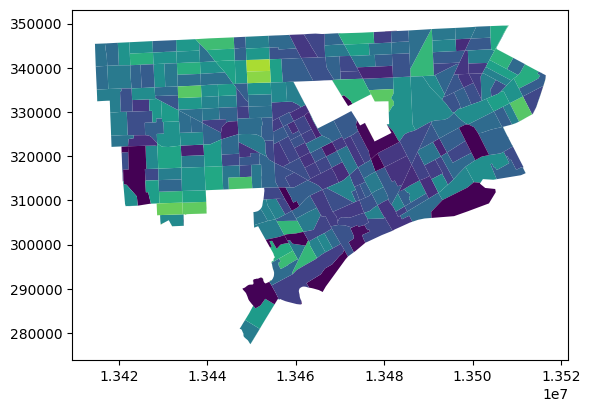

In [5]:
# filter ACS economic data to just detroit census tracts by joining census data to tracts
economic_tables = detroit_gdf.merge(economic_tables, left_on='TRACTCE', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe

economic_tables.plot(column = 'poverty_status')

## Indicator Group 2: Social
### Specific Indicator selected: Citizenship Status

Here, i used ACS tables 'B05001_001E':'universe of US Citizens', and 'B05001_006E':'Estimate!!Total:!!Not a U.S. citizen'. The actual indicator is percent of non-us citizens, so the code below adds a new column to the Social Factors dataframe called 'pct_non_US'. The values for this column are derived by dividing the 006E table by the 001E table for each row (tract). The output is a proportion, between 0-1. It can be made into a percentage by multiplying by 100% if needed.

In [6]:
acs_social = ['B05001_001E','B05001_006E'] # add additional acs table codes here
social_tables = c.acs5.get(acs_social, geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)})
social_tables = pd.DataFrame(social_tables) #converting to dataframe to do additional transformations


# for Indicator Group 2, final value is column 2 divided by column 1; so must create new column that equals 006E/001E
# also must handle if 001E == 0, to output 0 instead of an error

social_tables['pct_non_US'] = 0.0 # initialize column to 0, below will change if 001E does NOT equal 0, otherwise no change (stays 0.0)

social_tables['pct_non_US'] = np.where(       # only changing the value of 'pct_non_US' column where the denominator (001E) is not 0, preventing divide by zero error. 'pct_non-US' column is populated with the value of 006E/001E (which will be between 0-1)
    social_tables['B05001_001E'] != 0,
    social_tables['B05001_006E']/ social_tables['B05001_001E'], # if wanted, you can add the .round() method arround this expression to round the output. I think it may be better to leave everything un-rounded until the end.
    0
)


<Axes: >

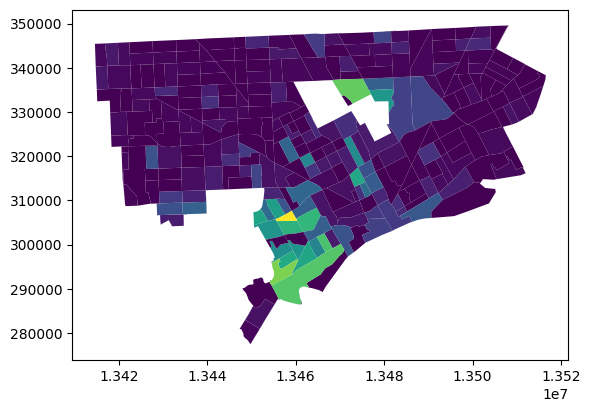

In [7]:
# filter ACS social data to just detroit census tracts by joining census data to tracts
social_tables = detroit_gdf.merge(social_tables, left_on='TRACTCE', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe
social_tables.plot(column = 'pct_non_US')

## Indicator Group 3: Housing
### Specific Indicator selected: Gross Rent

Here I used ACS table 'B25064_001E':'Median Gross rent' by tract

In [8]:
acs_housing = ['B25064_001E'] # add additional acs table codes here

housing_tables = c.acs5.get(acs_housing, geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)})

housing_tables = pd.DataFrame(housing_tables) #converting to dataframe to do additional transformations

housing_tables[acs_housing] = housing_tables[acs_housing].replace(-666666666.0, np.nan) # sometimes, census data has -666666.00 instead of null; reclassing all those to null using numpy NaN. Justification: it skews the normalization, but it shouldn't be zero, which would also skew the norm

housing_tables = housing_tables.rename(columns={'B25064_001E': 'med_gross_rent'}) # renaming the column for easy recognition (optional since the acs table code is more traceable)




<Axes: >

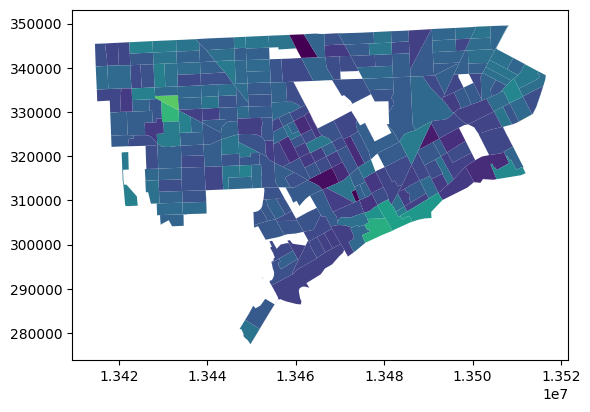

In [9]:
# filter ACS housing data to just detroit census tracts by joining census data to tracts
housing_tables = detroit_gdf.merge(housing_tables, left_on='TRACTCE', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe
housing_tables.plot(column = 'med_gross_rent')

## Indicator Group 4: Household
### Specific Indicator selected: Household Income

Here I used ACS table 'B19013_001E':'Median Household Income in the Past 12 Months (in 2024 Inflation-Adjusted Dollars)'

In [10]:
acs_household = ['B19013_001E'] # add additional acs table codes here

household_tables = c.acs5.get(acs_household, geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)})

household_tables = pd.DataFrame(household_tables) #converting to dataframe to do additional transformations

household_tables[acs_household] = household_tables[acs_household].replace(-666666666.0, np.nan) # sometimes, census data has -666666.00 instead of null; reclassing all those to null using numpy NaN. Justification: it skews the normalization, but it shouldn't be zero, which would also skew the norm

household_tables = household_tables.rename(columns={'B19013_001E': 'med_household_income'})


<Axes: >

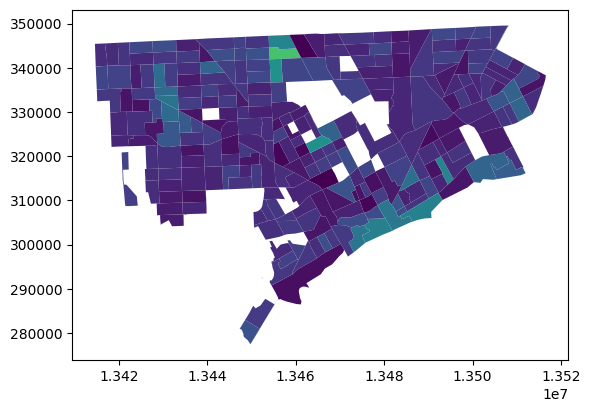

In [11]:
# filter ACS household data to just detroit census tracts by joining census data to tracts
household_tables = detroit_gdf.merge(household_tables, left_on='TRACTCE', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe
household_tables.plot(column = 'med_household_income')

## Indicator Group 5: Demographic
### Specific Indicator selected: Race and Ethnicity

For demographic, I used ACS Tables 'B02001_001E':'universe of Race: Estimate!!Total:' and 'B02001_002E':'Estimate!!Total:!!White alone'. The indicator according to Assaad and Jezzini is percent of the population that is white alone, so the process used for Indicator group 2 was repeated: I created a new column in the dataframe called 'pct_white_alone', which is calculated as the value of column 002E divided by the value of column 001E, except where 001E is 0, which will be left as zero as to avoid a 'divide by zero' error. 

In [12]:
acs_demographic = ['B02001_001E','B02001_002E'] # add additional acs table codes here

demographic_tables = c.acs5.get(acs_demographic, geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)})

demographic_tables = pd.DataFrame(demographic_tables) #converting to dataframe to do additional transformations

# for Indicator Group 2, final indicator value is column 2 divided by column 1; so must create new column that equals 002E/001E
# also must handle if 001E == 0, to output 0 instead of an error

demographic_tables['pct_white_alone'] = 0.0 # initialize column to 0, below will change if 001E does NOT equal 0, otherwise no change (stays 0.0)

demographic_tables['pct_white_alone'] = np.where( # only changing the value of 'pct_white_alone' column where the denominator (001E) is not 0, preventing divide by zero error. 'pct_white_alone' column is populated with the value of 002E/001E (which will be between 0-1)
    demographic_tables['B02001_001E'] != 0,
    demographic_tables['B02001_002E']/ demographic_tables['B02001_001E'], # if wanted, you can add the .round() method arround this expression to round the output. I think it may be better to leave everything un-rounded until the end.
    0
)


<Axes: >

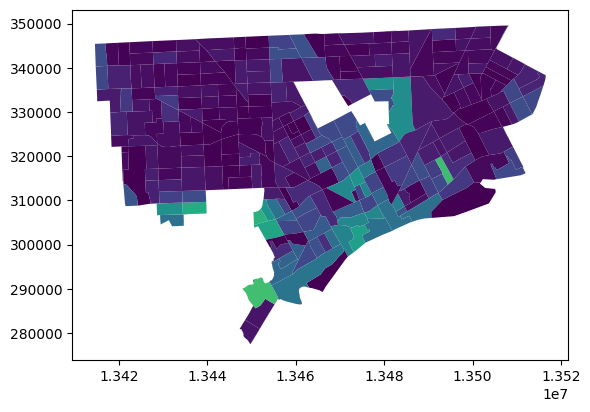

In [13]:
# filter ACS demographic data to just detroit census tracts by joining census data to tracts
demographic_tables = detroit_gdf.merge(demographic_tables, left_on='TRACTCE', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe
demographic_tables.plot(column = 'pct_white_alone')

## Indicator Group 7: Green Infrastructure (GIs)
### Specific Indicator Selected: GIs Frequency 
this is defined by Assaad and Jezzini as the number of green infrastructure projects per census tract. In my analysis below, I used only a dataset of Green *Stormwater* infrastructure projects, from the City of Detroit Open Data Portal. Thus, this indicator as-is represents Green Stormwater Infrastructure freqeuncy per census tract.

<Axes: >

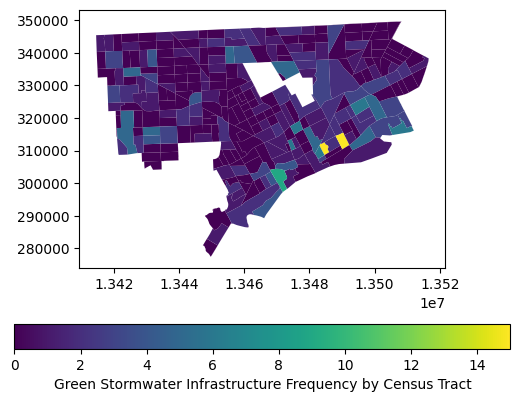

In [14]:
# Reproject census tracts GeoDataframe to NAD83 Michigan South (feet)
GSI_gdf = detroit_gdf.to_crs(2898)

# Reading in GSI locations via REST endpoint from Detroit Open Data Hub, reproject to NAD83
GSI_points = gpd.read_file("https://services2.arcgis.com/qvkbeam7Wirps6zC/arcgis/rest/services/Green_Stormwater_Infrastructure_Locations_OpenDataPortal/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson")
GSI_points = GSI_points.to_crs(2898)

# left-hand spatial join: assigning attributes of census tracts (mainly ID) to each point
join_left_df = GSI_points.sjoin(GSI_gdf, how="left")

counts = join_left_df.groupby('TRACTCE').size().rename('GSI_count') # this creates an array with the tract IDs and the count of points in each one (min of 1)
GSI_by_tract = GSI_gdf.merge(counts, left_on='TRACTCE', right_on='TRACTCE', how='left') # merging point counts with the original shapefile geometry, left-hand join to keep all tracts
GSI_by_tract['GSI_count'] = GSI_by_tract['GSI_count'].fillna(0).astype(int) # some tracts have no points, so changing NULL vals in point_count to 0

# plot map of tracts by count, to verify
GSI_by_tract.plot(column= 'GSI_count', legend = True, legend_kwds={"label": "Green Stormwater Infrastructure Frequency by Census Tract", "orientation": "horizontal"}) 


## Indicator Group 6: Amenities
### Specific Indicator selected: Proximity to schools

this is defined by Assaad and Jezzini as the distance from the centroid of the census tract to the nearest school point. They only include high school and post-secondary schools, while my code below uses all schools in Wayne County. I downloaded the shapefiles for K-12 schools and post-secondary schools from the National Center for Education Statistics (NCES). Then, I filtered by location and merged them into a single dataset.

<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:16: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:23: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:27: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:28: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will n

<Axes: >

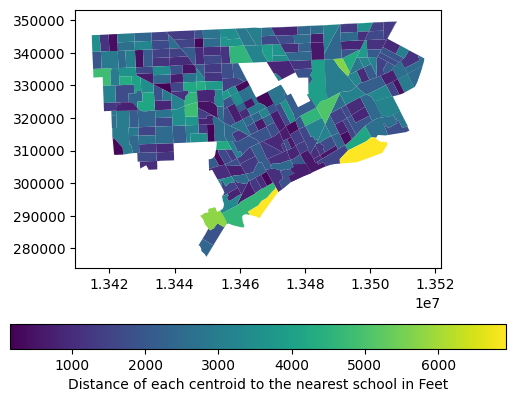

In [15]:

import zipfile

# Eventually want to use these URLs to grab zip files instead of using local downloads; having issues finding a non-complicated way to do that
#public_school_pts = "https://nces.ed.gov/programs/edge/data/EDGE_GEOCODE_PUBLICSCH_2425.zip"
#secondary_school_pts = "https://nces.ed.gov/programs/edge/data/EDGE_GEOCODE_POSTSECSCH_2425.zip"
destination1 = "data\outputs\schools\public_schools"
destination2 = "data\outputs\schools\secondary_schools"

public_school_pts = "EDGE_GEOCODE_PUBLICSCH_2425.zip"
secondary_school_pts = "EDGE_GEOCODE_POSTSECSCH_2425.zip"

# first, unzipping this data folder. Another zipfile is contained which also needs to be unzipped
with zipfile.ZipFile(public_school_pts, 'r') as zip_ref:
    zip_ref.extractall(destination1)

with zipfile.ZipFile("data\outputs\schools\public_schools\Shapefile_SCH.zip", 'r') as zip_ref:
    zip_ref.extractall(destination1)

# Second, unzipping Post Secondary schools locations (college/university)
with zipfile.ZipFile(secondary_school_pts, 'r') as zip_ref:
    zip_ref.extractall(destination2)

with zipfile.ZipFile("data\outputs\schools\secondary_schools\SHAPEFILE.zip", 'r') as zip_ref:
    zip_ref.extractall(destination2)

# Next, convert shapefiles to GDF to take a look at data schema. I want to filter schools down to State = MI and County = Wayne, then append one list onto the other
public_sch_file_path = Path("data\outputs\schools\public_schools\EDGE_GEOCODE_PUBLICSCH_2425.shp")
secondary_sch_file_path = Path("data\outputs\schools\secondary_schools\SHAPEFILE\EDGE_GEOCODE_POSTSECSCH_2425.shp")
pub_sch_gdf = gpd.read_file(current_dir / public_sch_file_path)
sec_sch_gdf = gpd.read_file(current_dir / secondary_sch_file_path)

# filtering
pub_sch_gdf = pub_sch_gdf[(pub_sch_gdf['STATE']== 'MI') & (pub_sch_gdf['NMCNTY'] == 'Wayne County')]
#print (pub_sch_gdf)

sec_sch_gdf = sec_sch_gdf[(sec_sch_gdf['STATE']== 'MI') & (sec_sch_gdf['NMCNTY'] == 'Wayne County')]
#print (sec_sch_gdf)

# appending filtered post secondary schools onto the public school list, to get list of all school locations in Wayne Co, MI
# NOTE: schools used in Assaad and Jezzini 2024 only includes high schools and post-secondary as gentrification indicators. My all_schools layer below contains all schools, K through college
all_schools = pd.concat([pub_sch_gdf,sec_sch_gdf], ignore_index= True)
all_schools = all_schools.to_crs(2898)
#print(all_schools)

# calculate centroid of the wayne county census tract polygons
detroit_gdf = detroit_gdf.to_crs(2898)
centroid_gdf = detroit_gdf.copy()
centroid_gdf.geometry = detroit_gdf.centroid

# Check centroid points by plotting census tracts with centroid points on top
#base = detroit_gdf.plot(color='white', edgecolor='black')
#centroid_gdf.plot(ax=base, marker='o', color='red', markersize=5);
#print(centroid_gdf)

# calculating the distance of each census tract centroid to the Nearest school point
# left hand spatial join to preserve the census centroid point data (particularly the census tract ID)
school_dist = centroid_gdf.sjoin_nearest(all_schools, distance_col= "dist_school_ft", how= "left")

# school_dist now contains a point layer with a column titled "dist_school_ft" which is the distance from the centroid to the nearest school point in feet
#print(school_dist)

# next, I want to take the column containing the distances, and stick it back onto the census geometry (this is just for visualization, as long as each distance still has a census tract ID, it can be used in the final calculations)
tracts_school_dist = detroit_gdf.merge(school_dist[['TRACTCE', 'dist_school_ft']], on='TRACTCE', how='left')

# plotting tracts by distance to nearest school
tracts_school_dist.plot(column= 'dist_school_ft', legend = True, legend_kwds={"label": "Distance of each centroid to the nearest school in Feet", "orientation": "horizontal"})

# if geometry isn't needed at this step, just use school_dist, which has the census tract ID ('TRACTCE') and the distance of the centroid to the nearest school ('dist_school_ft'). 
# the column 'dist_school_ft' is the raw value of the indicator.

# Data Preprocessing: Min-Max Normalization
From Assaad and Jezzini 2024: "the Min-Max technique was used to scale the data into a unitless and comparable scale"
**Equation: Zi= (Xi - Xmin)/(Xmax - Xmin)**, "where Zi, Xi, Xmin, and Xmax represent the scaled value, the original value, the minimum of the original value, and the maximum of the original value, respectively."

HOWEVER, indicators which have an *inverse* relationship to green gentrification are scaled using an Inverse Min-Max, as follows:
**Equation: Zi= 1 - ((Xi - Xmin)/(Xmax - Xmin))**

#### ACS Derived Indicators
* Poverty: **positive relationship**; more people in poverty means more risk of green gentrification (GG)
* Citizenship Status: **positive**: higher proportion of non-US citizens means more risk of GG
* Gross rent: **inverse relationship**; higher median gross rent means less vulnerability to GG
* Household Income: **inverse relationship**; higher household income means less vulnerability to GG
* Race and ethnicity: **inverse**; higher proportion of white-alone people means less vulnerability to GG

#### Spatial Indicators
* Proximity to schools: **inverse**; as distance to schools increases, vulnerability to GG decreases (areas near schools, i.e. lower distance, are more likely to be gentrified)
* GSI frequency: **positive**; tracts with more GSI infrastructure projects are more vulnerable to GG


### Positive Min-Max
#### Note: min-max normalization is performed below for indicators Citizenship Status and Race and Ethnicity, which are already proportions (percents of total tract population). This could introduce bias towards outliers, so methodology should be double-checked/made explicit

***Also note:*** in the code above that prepares the columns in each table, I have reclassified the -666666.0 values in the census ACS data (particularly relevant for median rent and median household income) to be NaN (aka null values). Originally I reclassed them to 0, but this messes up the normalization below. So, below, all rows which have NaN for the census table value, will have NaN added to the normalized value column, so that they aren't considered in the min-max, but not fully deleted from the dataset.

In [16]:
# Poverty: economic_tables, column 'poverty_status'
economic_tables['norm_poverty'] = 0.0 # min-max normalized column is named norm_poverty
economic_tables['norm_poverty'] = np.where( # where column is not NaN, calculate the min-max normalized value, else assign norm_poverty to NaN
    economic_tables['poverty_status'].notnull(),
    (economic_tables['poverty_status'] - economic_tables['poverty_status'].min())/(economic_tables['poverty_status'].max() - economic_tables['poverty_status'].min()),
    np.nan
)

# Citizenship Status: social_tables, column 'pct_non_US'
social_tables['norm_non_US'] = 0.0 # min-max normalized column is named norm_non_US
social_tables['norm_non_US'] = np.where( # where column is not NaN, calculate the min-max normalized value, else assign norm_non_us to NaN
    social_tables['pct_non_US'].notnull(),
    (social_tables['pct_non_US'] - social_tables['pct_non_US'].min())/(social_tables['pct_non_US'].max() - social_tables['pct_non_US'].min()),
    np.nan
)

# GSI frequency: GSI_by_tract, column 'GSI_count'
GSI_by_tract['norm_GSI_count'] = 0.0
GSI_by_tract['norm_GSI_count'] = (GSI_by_tract['GSI_count'] - GSI_by_tract['GSI_count'].min())/(GSI_by_tract['GSI_count'].max() - GSI_by_tract['GSI_count'].min())


### Inverse Min-Max

In [17]:
# Gross Rent: housing_tables, column 'med_gross_rent'
housing_tables['norm_gross_rent'] = 0.0
housing_tables['norm_gross_rent'] = np.where( # where column is not NaN, calculate the min-max normalized value, else assign norm_gross_rent to NaN
    housing_tables['med_gross_rent'].notnull(),
    1-((housing_tables['med_gross_rent'] - housing_tables['med_gross_rent'].min())/(housing_tables['med_gross_rent'].max() - housing_tables['med_gross_rent'].min())),
    np.nan
)

# Household Income: household_tables, column 'med_household_income'
household_tables['norm_household_income'] = 0.0
household_tables['norm_household_income'] = np.where( # where column is not NaN, calculate the min-max normalized value, else assign norm_household_income to NaN
    household_tables['med_household_income'].notnull(),
    1-((household_tables['med_household_income'] - household_tables['med_household_income'].min())/(household_tables['med_household_income'].max() - household_tables['med_household_income'].min())),
    np.nan
)

# Race and ethnicity: demographic_tables, column 'pct_white_alone'
# NOTE normalizing a proportion... can comment out code below or set 'norm_white_alone' = 'pct_white_alone' to not re-normalize the distribution
demographic_tables['norm_white_alone'] = 0.0
demographic_tables['norm_white_alone'] = np.where( # where column is not NaN, calculate the min-max normalized value, else assign norm_white_alone to NaN
    demographic_tables['pct_white_alone'].notnull(),
    1-((demographic_tables['pct_white_alone'] - demographic_tables['pct_white_alone'].min())/(demographic_tables['pct_white_alone'].max() - demographic_tables['pct_white_alone'].min())),
    np.nan
)

# Proximity to schools: school_dist, column 'dist_school_ft'
school_dist['norm_sch_dist_ft'] = 0.0
school_dist['norm_sch_dist_ft'] = 1-((school_dist['dist_school_ft'] - school_dist['dist_school_ft'].min())/(school_dist['dist_school_ft'].max() - school_dist['dist_school_ft'].min()))




# Data Preprocessing: checking suitability of data for Principle Component Analysis
#### In order to verify that performing PCA would give valid results, the data must pass the KMO test of sampling adequacy as well as the Bartlett's sphericity test. PCA will be applied to each of the seven categories. Thus, I believe that these suitability tests will be done per category, to determine reduncancy of indicator variables within each indicator category. According to Assaad and Jezzini 2024, the data is considered suitable for PCA when the KMO test value is greater than 0.5, and the Bartlett's p-value is significant at less than or equal to 0.05. 

I will use the factor_analyser library for python, importing calculate_kmo and calculate_bartlett_sphericity. Code sources/library help for this section is from: https://www.datacamp.com/tutorial/introduction-factor-analysis

**Some Considerations:**
* for the purposes of this project, I have only selected one indicator from each of the seven categories, meaning these tests (and category-level PCA) will not be successful/make sense
* KMO and Bartlett tests cannot handle NaN values, so this will need to be considered for the final dataset. 

In [18]:
# below is pseudocode that could be developed to perform the category-level validity tests

#from factor_analyzer.factor_analyzer import calculate_kmo
#from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

# the tests may only consider numeric data, so I will create copy dataframes that containn only the normalized indicator values. I will also .dropna() to remove NaN from the copy df's
# these new dataframes will be named df1-7, for each of the 7 categories defined above
# the outputs of the test will also be labeled with numbers correlating to their category number, i.e. for group 1, Economic factors: df1, kmo_all_1, kmo_model_1, chi_1, p_1
# I can add all of the variables to a final table with columns for the test output vars, where each row corresponds to the category group number
validity_results = pd.DataFrame(columns=['group','kmo_all','kmo_model','bs_chi_square','bs_p_value'])

# Indicator Group 1: Economic Factors
df1 = economic_tables.filter(regex='^norm_').copy().dropna() # this creates a copy of the economic tables dataframe, but only keeps columns whose names begin with "norm_" (so getting rid of the raw data and the census/state/county). Requires that normalized columns all use the same naming convention!!!

# following rows are commented out in order to keep code running

#kmo_all_1, kmo_model_1 = calculate_kmo(df1) # Group 1 KMO test (all means the KMO when using all values, model means KMO for subset of vars which are suitable)
#chi_1, p_1 = calculate_bartlett_sphericity(df1) # Group 1 Bartlett test
#validity_results.loc[0] = [1,kmo_all_1,kmo_model_1,chi_1,p_1] # add test data to the first row of the validity test results table

# NOTE: Repeat with next 6 groups, following naming convention

# Indicator Group 2: Social Factors
df2 = social_tables.filter(regex='^norm_').copy().dropna() # this creates a copy of the economic tables dataframe, but only keeps columns whose names begin with "norm_" (so getting rid of the raw data and the census/state/county). Requires that normalized columns all use the same naming convention!!!
#kmo_all_2, kmo_model_2 = calculate_kmo(df2) # Group 2 KMO test (all means the KMO when using all values, model means KMO for subset of vars which are suitable)
#chi_2, p_2 = calculate_bartlett_sphericity(df1) # Group 2 Bartlett test
#validity_results.loc[1] = [2,kmo_all_1,kmo_model_1,chi_1,p_1] # add test data to the second row of the validity test results table

# etc. can only run once at least two indicator columns are added to each categories' dataframe


after this, verify that validity_results table has valid results. kmo_model should be >0.5 and bs_p_value should be less than/equal to 0.05

# Calculating Weights with PCA 

To aid in calculating eigenvalues and variance, I'll  use the scikitlearn decomposition module; documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

From Assaad and Jezzini 2024:
"To weigh the green gentrification indicators, PCA was applied separately to each of the 7 categories of green gentrification indicators (see Fig. 1). Then the weight of each indicator with respect to its category was calculated based on Eqs. (3), (4), (5)."

Eqn (3): P_ijk = ((p_ijk)^2)/L_jk
* i is indicator in category k; j is the principle component
* P_ijk is the ratio of the variance in the data explained by each indicator within its category, compared to the variance explained by the principle component alone
* p_ijk is the factor loading of indicator i in principle component j
* L_jk is the eigenvalue of principle component j (and is calculated as the sum of (p_ijk)^2 for all indicators in one category) 

Eqn (4): phi_jk = L_jk / sum(L_jk)
* phi_jk is the ratio of variance explained by j to the sum of variance explained by all principle components in category k

Eqn (5): w_ik = sum(phi_jk * P_ijk) 
* w_ik is the weight of indicator i within category k; sum of phi_jk * P_ijk for all principle components 


In [19]:
# below is pseudocode for calculating weights; not possible until I add additional indices to each category

# from sklearn.decomposition import PCA

# # Group 1 PCA: Economic factors
# pca_1 = PCA(n_components = 5) # there are (eventually) 5 indicators in the Economic factors group
# pca_1_features = pca_1.fit_transform(df1) # calculates weight and variance and converts columns to principle component scores



## Calculating vulnerability score for each category

Eqn (6): V_k = sum( w_ik * Z_ik)
* V_k is the vulnerability score of the census tract of category k
* w_ik is the weight of indicator i in category k
* Z_ik is the normalized indicator value (in the norm_[category] columns)
* the sum is adding the weight times the indicator value for all indicators in the catgory


## PCA sub-step: calculating the weights of vulnerability scores with respect to GGVI

essentially, repeat steps above but using the output Vk as the input for PCA: 1 overall category representing GGVI, and 7 component groups (indicator categories 1-7). The final output (eqn 6) is Wk, which represents the weights of vulnerability scores

In [20]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
 
 
def compute_indicator_weights(data: np.ndarray) -> tuple[np.ndarray, PCA]:
    """
    Given normalised indicator data for ONE category, return the PCA-derived
    weight for every indicator.  Weights sum to 1.
 
    Parameters
    ----------
    data : array of shape (n_census_tracts, n_indicators)
 
    Returns
    -------
    weights : array of shape (n_indicators,)
    pca     : fitted PCA object
    """
    n_tracts, n_indicators = data.shape
 
    # ──────────────────────────────────────────────────────────────────
    # STEP 1 ▸ Run PCA  (keep every component; we'll filter next)
    # ──────────────────────────────────────────────────────────────────
    pca = PCA(n_components=n_indicators)
    pca.fit(data)
 
    eigenvalues = pca.explained_variance_            # one per component
    variance_pct = pca.explained_variance_ratio_     # fraction of total variance
 
    # ──────────────────────────────────────────────────────────────────
    # STEP 2 ▸ Decide which components to keep
    #   Paper's three rules (all must be true for a component):
    #     • eigenvalue > 1
    #     • explains ≥ 10 % of variance on its own
    #     • stop once cumulative explained variance exceeds 60 %
    # ──────────────────────────────────────────────────────────────────
    kept_components = []
    cumulative_variance = 0.0
 
    for j in range(len(eigenvalues)):
        big_enough    = eigenvalues[j] > 1
        explains_10   = variance_pct[j] >= 0.10
 
        if big_enough and explains_10:
            kept_components.append(j)
            cumulative_variance += variance_pct[j]
            if cumulative_variance > 0.60:
                break
 
    # Safety net: always keep at least the first component
    if not kept_components:
        kept_components = [0]
 
    # ──────────────────────────────────────────────────────────────────
    # STEP 3 ▸ Compute factor loadings for the kept components
    #
    #   A "factor loading" tells you how strongly each indicator
    #   correlates with a given principal component.
    #
    #   Formula:  loading = eigenvector × √(eigenvalue)
    #
    #   sklearn stores eigenvectors in pca.components_ (one row per PC).
    # ──────────────────────────────────────────────────────────────────
    all_loadings = np.zeros_like(pca.components_)
    for j in range(len(eigenvalues)):
        for i in range(n_indicators):
            all_loadings[j, i] = pca.components_[j, i] * np.sqrt(eigenvalues[j])
 
    # ──────────────────────────────────────────────────────────────────
    # STEP 4 ▸ Equation (3)  — "How much of component j's variance
    #           does indicator i explain?"
    #
    #   ρ̄_ij = loading_ij² / eigenvalue_j
    #
    #   Squaring the loading gives the variance contributed by that
    #   indicator to that component.  Dividing by the eigenvalue
    #   (= total variance of the component) turns it into a fraction.
    #   All ρ̄ values for one component sum to 1.
    # ──────────────────────────────────────────────────────────────────
    rho_bar = {}  # keyed by (component_index, indicator_index)
 
    for j in kept_components:
        for i in range(n_indicators):
            loading = all_loadings[j, i]
            rho_bar[(j, i)] = (loading ** 2) / eigenvalues[j]
 
    # ──────────────────────────────────────────────────────────────────
    # STEP 5 ▸ Equation (4)  — "How important is component j compared
    #           to the other kept components?"
    #
    #   Φ_j = eigenvalue_j / (sum of eigenvalues of all kept components)
    #
    #   This gives each kept component a share that sums to 1.
    # ──────────────────────────────────────────────────────────────────
    total_eigenvalue_kept = sum(eigenvalues[j] for j in kept_components)
 
    phi = {}  # keyed by component_index
    for j in kept_components:
        phi[j] = eigenvalues[j] / total_eigenvalue_kept
 
    # ──────────────────────────────────────────────────────────────────
    # STEP 6 ▸ Equation (5)  — "Final weight for each indicator"
    #
    #   ω_i = Σ_j  (Φ_j × ρ̄_ij)
    #
    #   For every indicator, walk through the kept components and
    #   accumulate:  (component importance) × (indicator's share in
    #   that component).  The result across all indicators sums to 1.
    # ──────────────────────────────────────────────────────────────────
    weights = np.zeros(n_indicators)
 
    for i in range(n_indicators):
        for j in kept_components:
            component_importance   = phi[j]
            indicator_share_in_j   = rho_bar[(j, i)]
            weights[i] += component_importance * indicator_share_in_j
 
    return weights, pca


<Axes: >

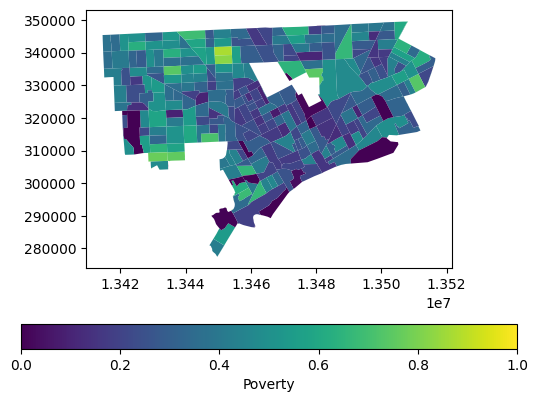

In [21]:
economic_tables.plot(column = 
    'norm_poverty',
    legend=True,
    legend_kwds={"label": "Poverty", "orientation": "horizontal"}
    )


In [22]:
economic_tables["TRACTCE"]        = economic_tables["TRACTCE"].astype(int)
social_tables["TRACTCE"]          = social_tables["TRACTCE"].astype(int)
GSI_by_tract["TRACTCE"]       = GSI_by_tract["TRACTCE"].astype(int)
housing_tables["TRACTCE"]         = housing_tables["TRACTCE"].astype(int)
household_tables["TRACTCE"]       = household_tables["TRACTCE"].astype(int)
demographic_tables["TRACTCE"]     = demographic_tables["TRACTCE"].astype(int)
school_dist["TRACTCE"]        = school_dist["TRACTCE"].astype(int)



economic_tables_1 = economic_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
social_tables_1 = social_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
GSI_by_tract_1 = GSI_by_tract.set_index("TRACTCE").filter(regex='^norm_').copy()
housing_tables_1 = housing_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
household_tables_1 = household_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
demographic_tables_1 = demographic_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
school_dist_1 = school_dist.set_index("TRACTCE").filter(regex='^norm_').copy()

final_df = [
    economic_tables_1,
    social_tables_1,
    GSI_by_tract_1,
    housing_tables_1,
    household_tables_1,
    demographic_tables_1,
    school_dist_1
]

final_df = economic_tables_1.merge(social_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(GSI_by_tract_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(housing_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(household_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(demographic_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(school_dist_1, how='outer', left_index=True, right_index=True)




In [23]:
final_df = final_df.drop_duplicates()

# export to csv with nulls, but without the duplicative rows
final_df.to_csv("data\outputs\indicators_table.csv")


final_df = final_df.dropna()

<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\ashto\AppData\Local\Temp\ipykernel_16740\34905045.py:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  final_df.to_csv("data\outputs\indicators_table.csv")


In [24]:
weights = compute_indicator_weights(final_df)[0]
print(weights)

def calc_GGVI(row):
    sum = 0
    for i, val in enumerate(row):
        sum += weights[i] * val
    return sum

GGVIs = final_df.apply(calc_GGVI, axis=1).to_frame('GGVI')

# do something else like create a new column in final_df where the value equals the calc_GGVI? or initialize the GGVIs dataframe??

[0.12515163 0.15448065 0.00185159 0.01084098 0.0462706  0.63099302
 0.03041154]


<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\ashto\AppData\Local\Temp\ipykernel_16740\1301942468.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  file_path = Path("data\detroit_shapefile_2024\GGVI_census_tract.shp")


<Axes: >

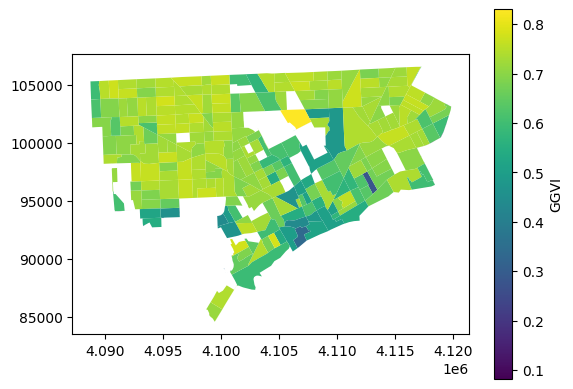

In [25]:
file_path = Path("data\detroit_shapefile_2024\GGVI_census_tract.shp")
# Read in census tracts shapefile as GeoDataframe
census_tracts_df = gpd.read_file(current_dir / file_path)
census_tracts_df['TRACTCE'] =  census_tracts_df['TRACTCE'].astype(int)
merged_tracts = census_tracts_df.merge(GGVIs, left_on='TRACTCE', right_on='TRACTCE', how='left') # Join census output dataframe to shapefile dataframe


merged_tracts.plot(
    column= 'GGVI',
    legend=True,
    legend_kwds={"label": "GGVI", "orientation": "vertical"},
)

In [26]:
#can't save as ashapefile unless column titled 0 is renamed to not be an integer... but idk how to do that
#merged_tracts = merged_tracts.rename(columns={merged_tracts['new_name']: 'GGVI_score'}, inplace=True)


# convert geodataframe to shapefile

merged_tracts.to_file("data/outputs/GGVI_DETROIT.shp")

c:\Users\ashto\Documents\GGVI-Capstone\env\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field CreationDa created as String field, though DateTime requested.
  ogr_write(
c:\Users\ashto\Documents\GGVI-Capstone\env\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field EditDate created as String field, though DateTime requested.
  ogr_write(
